In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# ถ้า Profit < 0 = ขาดทุน (1), ถ้า Profit >= 0 = กำไร (0)
df['Loss_Flag'] = (df['Profit'] < 0).astype(int)
print(df['Loss_Flag'].value_counts())

Loss_Flag
0    8123
1    1871
Name: count, dtype: int64


In [5]:
features = ['Sales', 'Quantity', 'Discount']

X = df[features]
y = df['Loss_Flag']

print(X.shape)

(9994, 3)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")

Train: 7995 rows
Test: 1999 rows


In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Training complete!")

Training complete!


In [8]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['กำไร', 'ขาดทุน']))

              precision    recall  f1-score   support

        กำไร       0.96      0.97      0.97      1636
      ขาดทุน       0.87      0.82      0.84       363

    accuracy                           0.94      1999
   macro avg       0.91      0.90      0.91      1999
weighted avg       0.94      0.94      0.94      1999



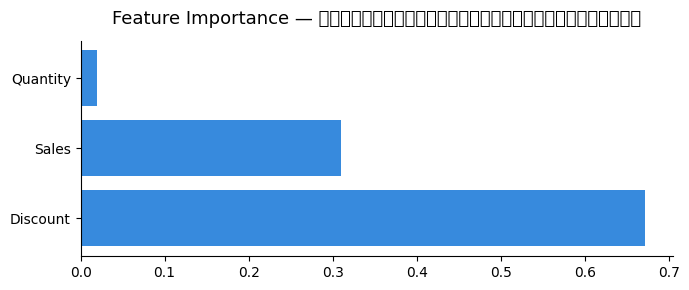

In [9]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(importance['Feature'], importance['Importance'],
        color='#378ADD', edgecolor='none')
ax.set_title('Feature Importance — อะไรส่งผลต่อการขาดทุนมากที่สุด',
             fontsize=13, pad=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
for _, row in importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']*100:.1f}%")

Discount: 67.1%
Sales: 31.0%
Quantity: 1.9%
